***
# Telecom-loyal Customer

## Data understanding
***
¶
The reason for selecting Telecom-Customer dataset is to find factors affecting on customer churn and cluster loyal customers.

Content: Each row represents a customer, each column contains customer’s attributes as described in the column Metadata.

The data set includes information about:
* Customers who left or stayed with Telco – the column is called Churn
* Services each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* Customer account information – customer tenure, contract Length, payment methods, paperless billin option, monthly charges, and total charges
* Demographic info about customers – gender, age, and if they have partners and dependents

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set(color_codes=True)

In [2]:
df=pd.read_csv('.../Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Data preparation:
As following the code  used to, first convert the argument to a numeric data type as well as the process of assessing the dataset for missing values, there were 11 missing values. 

In [4]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df.dropna(inplace = True)

In [6]:
df1 = df.iloc[:,1:]

#transform to binary code
df1['Churn'].replace(to_replace='Yes', value=1, inplace=True)
df1['Churn'].replace(to_replace='No',  value=0, inplace=True)

df_dummies = pd.get_dummies(df1)
df_dummies.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,1,...,0,1,0,0,0,1,0,0,1,0
1,0,34,56.95,1889.50,0,0,1,1,0,1,...,0,0,1,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,1,1,0,1,...,0,1,0,0,0,1,0,0,0,1
3,0,45,42.30,1840.75,0,0,1,1,0,1,...,0,0,1,0,1,0,1,0,0,0
4,0,2,70.70,151.65,1,1,0,1,0,1,...,0,1,0,0,0,1,0,0,1,0


In [7]:
# Statictice information and Variables relationshipe
df_dummies.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785,0.495307,0.504693,0.517491,0.482509,0.701507,...,0.388367,0.551052,0.209329,0.239619,0.407281,0.592719,0.219283,0.216297,0.336320,0.228100
std,0.368844,24.545260,30.085974,2266.771362,0.441782,0.500014,0.500014,0.499729,0.499729,0.457629,...,0.487414,0.497422,0.406858,0.426881,0.491363,0.491363,0.413790,0.411748,0.472483,0.419637
min,0.000000,1.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


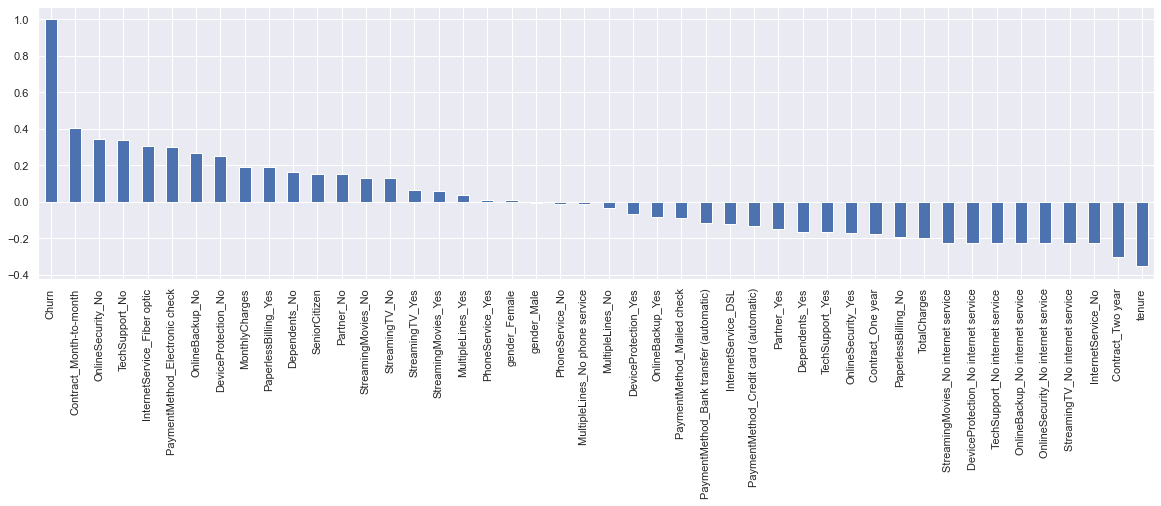

In [8]:
# correlation in glimps:
df_corr= df_dummies.iloc[:,0:]

plt.figure(figsize=(20,5))
df_corr.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

The figure shows:
* Correlation of gender, SeniorCitizen, Partner and Dependents with Churn are low. 
* Month to month contracts, absence of online security and tech support seem to be positively correlated with churn.While, tenure, two year contracts seem to be negatively correlated with churn.
* It seems that 'OnlineSecurity','TechSupport','InternetService_DSL','OnlineBackup','DeviceProtection' have lower correlation whith churn.

# <div >Data Exploration</div>

 For data exploration at first I will look at the distribution of individual variables and then check relation of the with churn.The variables are seen in two groups:Demography and customer account information.

### A. Check Demography of Dataset

#### Distribution of Demographic variables ( Gender, Senior citizen, Partner and Dependent):

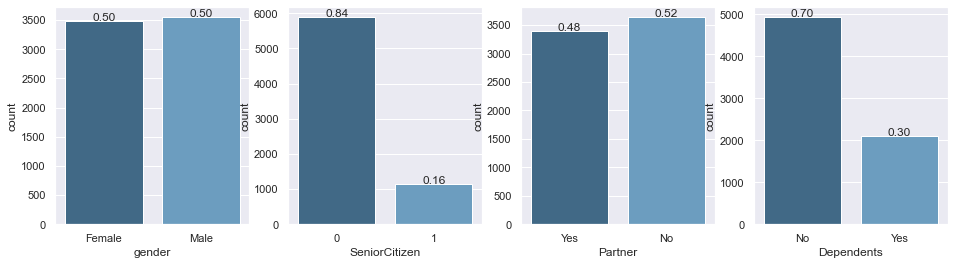

In [9]:

figure, axes = plt.subplots(nrows=1, ncols=4,figsize=(16,4))

total = float(len(df)) 
ax=sns.countplot(x="gender", data=df, palette="Blues_d",ax=axes[0])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    ax.set_aspect('auto')
    
total = float(len(df))
ax=sns.countplot(x="SeniorCitizen", data=df, palette="Blues_d",ax=axes[1])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    ax.set_aspect('auto')
    
total = float(len(df)) 
ax=sns.countplot(x="Partner", data=df, palette="Blues_d",ax=axes[2])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    ax.set_aspect('auto')

total = float(len(df)) 
ax=sns.countplot(x="Dependents", data=df, palette="Blues_d",ax=axes[3])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
ax.set_aspect('auto')

plt.show()
 

Demography Results:
* Half of the customers are male and the other half are female
* 16% of the customers are senior citizens and most of customers are younger people.
* About 50% of the customers have a partner
* 30% of the total customers have dependents.

#### Relationship between demographic Characteristics and Churn

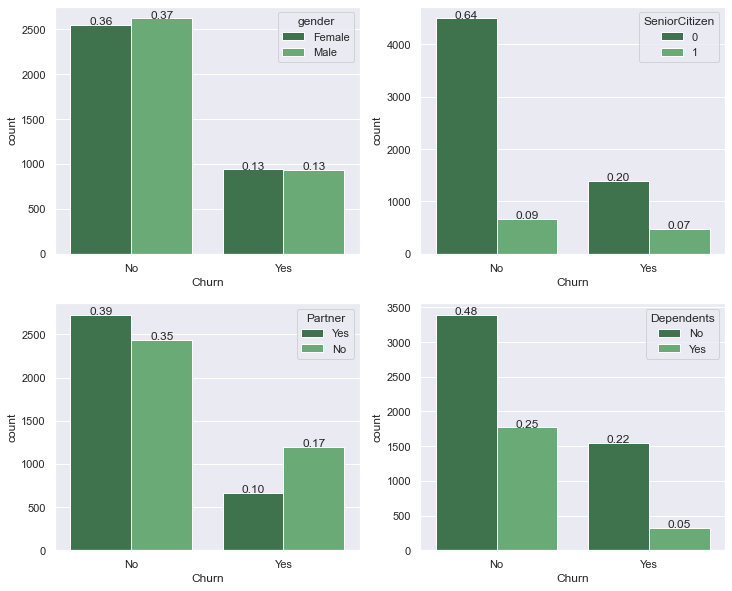

In [10]:
figure, axes = plt.subplots(nrows=2, ncols=2,figsize=(12,10))

total = float(len(df)) 
ax = sns.countplot(x="Churn", data=df,hue='gender', palette="Greens_d", ax=axes[0,0])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

total = float(len(df)) 
ax = sns.countplot(x="Churn", data=df,hue='SeniorCitizen', palette="Greens_d",ax=axes[0,1])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

total = float(len(df)) 
ax = sns.countplot(x="Churn", data=df,hue='Partner', palette="Greens_d", ax=axes[1,0])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    
total = float(len(df)) 
ax = sns.countplot(x="Churn", data=df,hue='Dependents', palette="Greens_d", ax=axes[1,1])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    ax.set_aspect('auto')

plt.show()

Observations:
* Both Genders seem to churn at a similar rate. 
* Customers considered Senior Citizens have a significantly higher rate of churn.
* Customers with a partner seem less likely to churn.
* While customers without dependents are less likely to churn in general, they make up the bulk of customers who have churn.

### B: Customer Account Information 

#### Churn distribution
 Churn  of customers from Telco is not equally distributed.

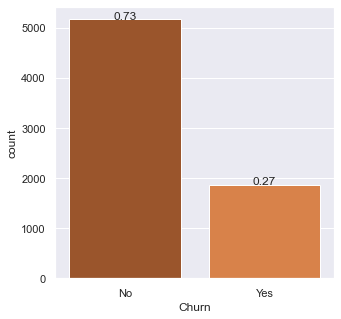

In [11]:
f, ax = plt.subplots(figsize=(5,5))
total = float(len(df)) 
ax = sns.countplot(x="Churn", data=df, palette="Oranges_d")
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

#### Tenure Info:
Tenure is between 1 and 72 month;

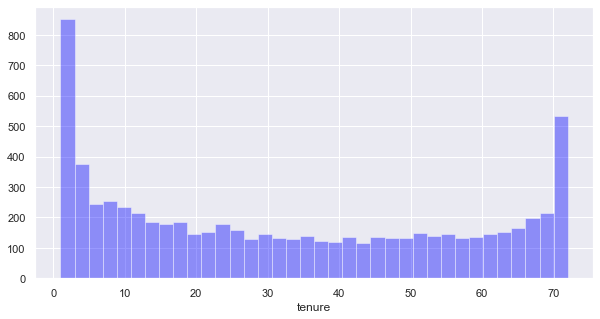

In [12]:
f, ax = plt.subplots(figsize=(10, 5))
ax = sns.distplot(df['tenure'], hist=True, kde=False, 
             bins=36, color = 'blue')



#### Contract,PaymentMethod,Billing info:
* most of the customers are in the month to month contract and the number of customers in the 1 year and 2 year contracts are almost equal.
* Electronic check method has the highest number of customers for payment and others almost equal
* 58% of customers have paperless billing and there are just 10% differences with paper billing. 

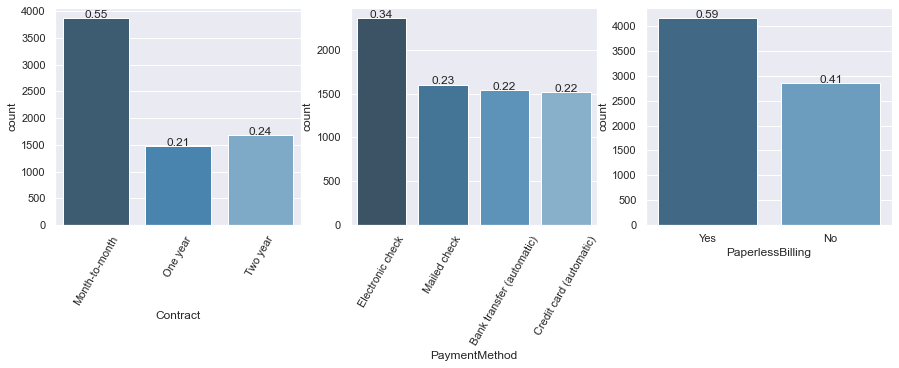

In [13]:
figure, axes = plt.subplots(nrows=1, ncols=3,figsize=(15,4))

total = float(len(df)) 
ax = sns.countplot(x="Contract", data=df, palette="Blues_d", ax=axes[0])
ax.set_xticklabels(ax.get_xticklabels(),rotation=60)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
ax.set_aspect('auto')

total = float(len(df)) 
ax = sns.countplot(x="PaymentMethod", data=df, palette="Blues_d", ax=axes[1])
ax.set_xticklabels(ax.get_xticklabels(),rotation=60)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

    
total = float(len(df)) 
ax = sns.countplot(x="PaperlessBilling", data=df, palette="Blues_d",  ax=axes[2])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    
ax.set_aspect('auto')
        
plt.show()

#### Services info:
Phone services have a higher number of customers and other services almost in the same range. 

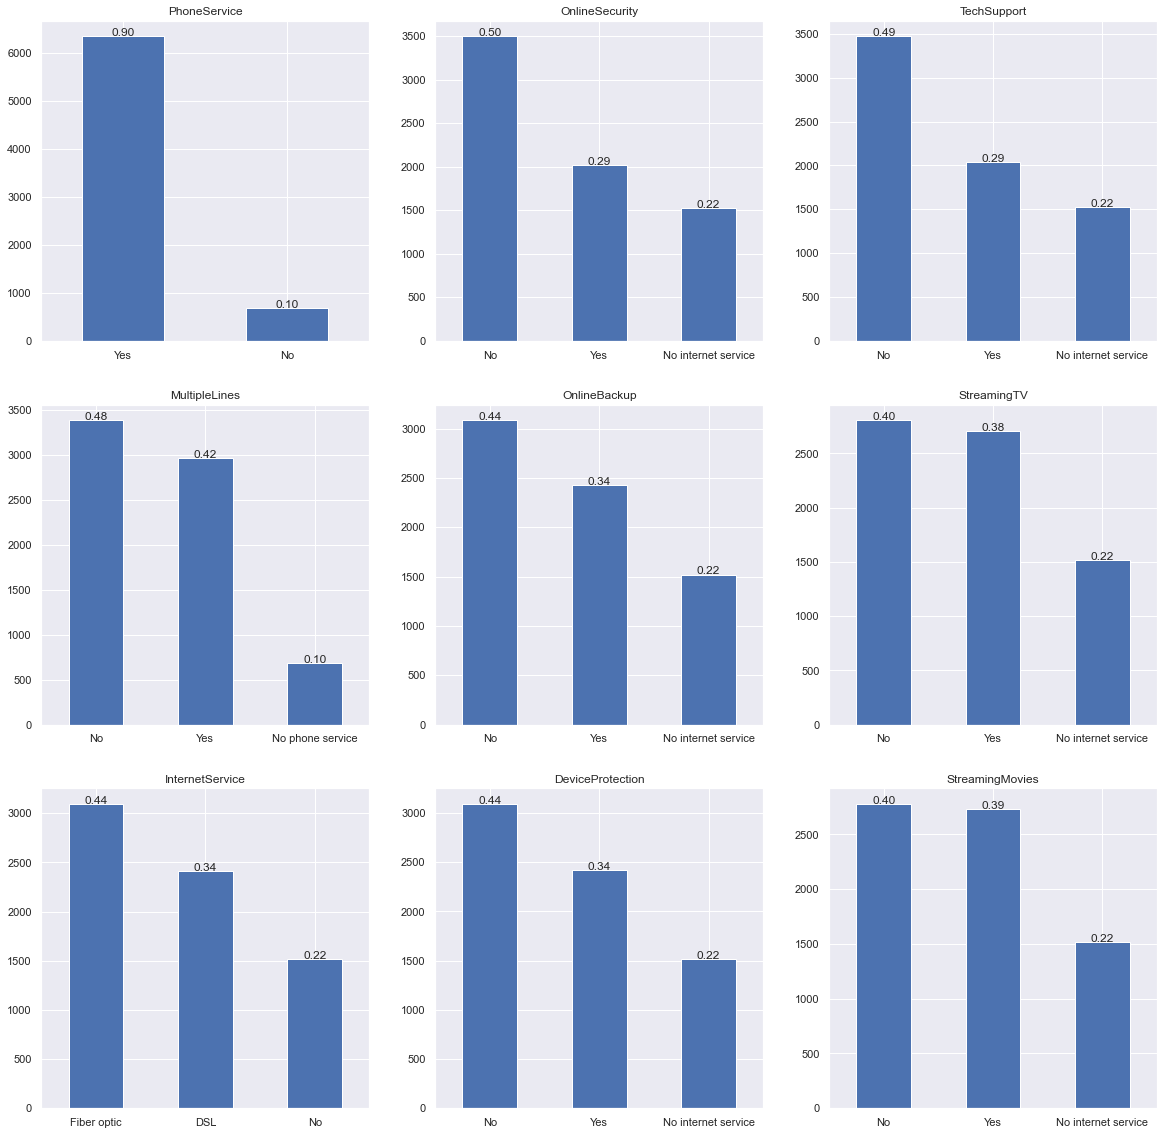

In [14]:
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
total = float(len(df))
fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (20,20))
for i, item in enumerate(services):
    if i < 3:
        ax = df[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0)
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
        
    elif i >=3 and i < 6:
        ax = df[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1],rot = 0)
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    
    elif i < 9:
        ax = df[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0)
        for p in ax.patches:
            height = p.get_height()
            ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
    ax.set_title(item)

#### Charges:
The large number of customers have low charges and some of  the total charges increases as the monthly bill for a customer increases. 

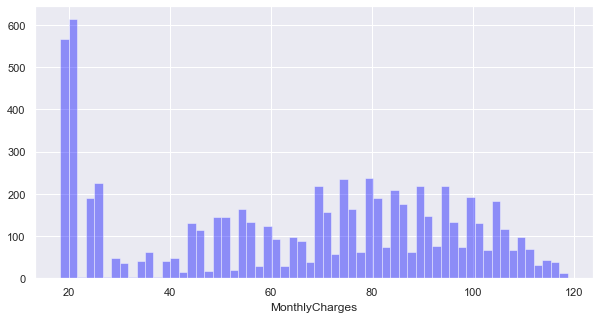

In [15]:
f, ax = plt.subplots(figsize=(10, 5))
ax = sns.distplot(df['MonthlyCharges'], hist=True, kde=False, 
             bins=60, color = 'blue')

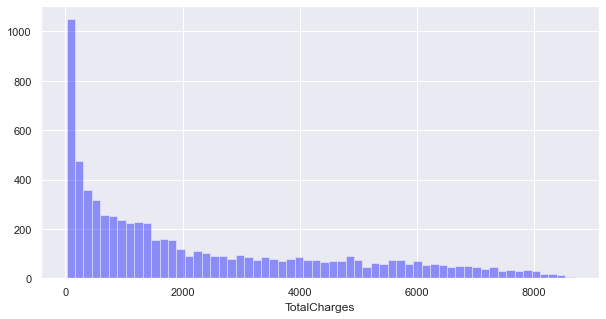

In [16]:
f, ax = plt.subplots(figsize=(10, 5))
ax = sns.distplot(df['TotalCharges'], hist=True, kde=False, 
             bins=60, color = 'blue')

#### Relationship Between Churn and Customer info:

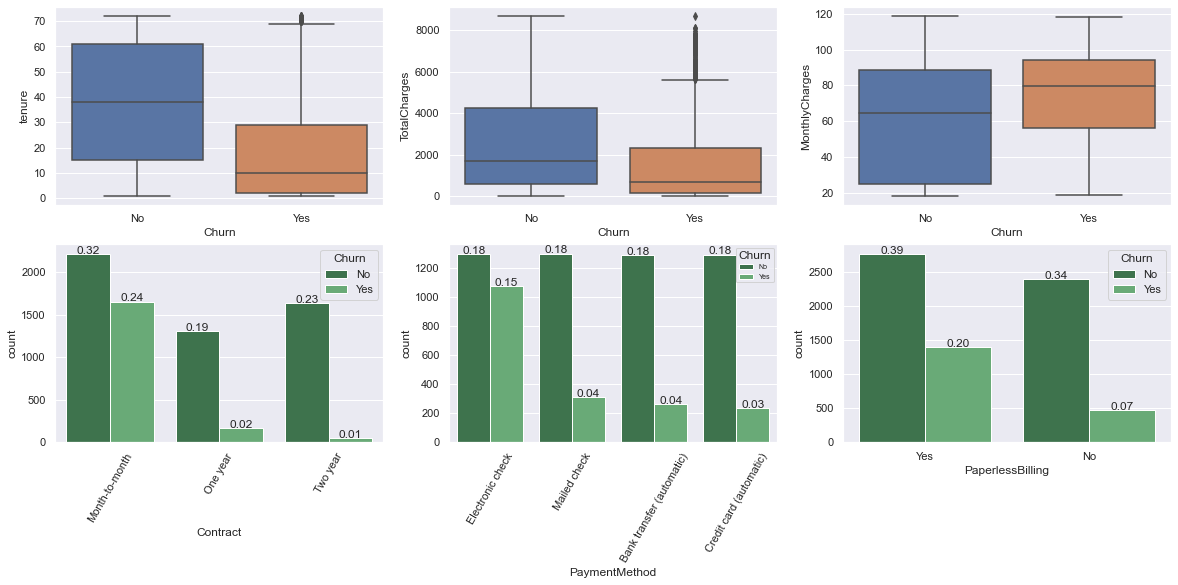

In [17]:
figure, axes = plt.subplots(nrows=2, ncols=3,figsize=(20,8))

ax= sns.boxplot(x="Churn", y="tenure", data=df, dodge=False, ax=axes[0,0]);


ax= sns.boxplot(x="Churn", y="TotalCharges", data=df, dodge=False,  ax=axes[0,1]);


ax= sns.boxplot(x="Churn", y="MonthlyCharges", data=df, dodge=False,  ax=axes[0,2]);



total = float(len(df)) 
ax = sns.countplot(x="Contract",hue="Churn", data=df, palette="Greens_d",  ax=axes[1,0])
ax.set_xticklabels(ax.get_xticklabels(),rotation=60)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

total = float(len(df))
ax = sns.countplot(x="PaymentMethod",hue="Churn", data=df, palette="Greens_d",  ax=axes[1,1])
ax.legend(loc='best',prop={'size':7},title = 'Churn')
ax.set_xticklabels(ax.get_xticklabels(),rotation=60)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")

            
total = float(len(df)) 
ax = sns.countplot(x="PaperlessBilling",hue="Churn", data=df, palette="Greens_d",  ax=axes[1,2])
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}'.format(height/total),
            ha="center")
ax.set_aspect('auto')


plt.show()

Observations:
* Persons on monthly contracts, among those who have churned, are most likely to do leave.
* Tenure ranges from 1 to 72 months, persons with tenures more than 30 months seem most likely to remain with the company.
* those who churned, persons who opt for Paper Billing have a lower rate of churn.
* Automatic payments (Credit card, Bank transfer) show lower levels of churn.
* Higher percent of customers churn when the monthly charges are high while there is higher churn when the total charges are lower.


## Modeling
### Supervised Learning:
Three classification models were used to predict the likelihood of customer churn and find important factors affect on churn:
* Decision Tree
* Random Forest
* Logistic Regression


In [18]:
from scipy import stats, integrate
from sklearn import metrics
from sklearn.model_selection import train_test_split

#### Scaling: 
The df_dummies dataset was then separated into Y output variable and X input variables. X is then transformed  to ensure that each variable is in a given range on the training set, in this case it is 0,1, the same as the y variable.


In [19]:
y = df_dummies['Churn'].values
x = df_dummies.drop(columns = ['Churn'])

from sklearn.preprocessing import MinMaxScaler
features = x.columns.values
scaler = MinMaxScaler(feature_range = (0,1))
scaler.fit(x)
x = pd.DataFrame(scaler.transform(x))
x.columns = features

#### Splitting testing and training the data:
A 20/80 testing and training split was applied.

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=0)

#### A: Decsion Trees 

In [21]:
from sklearn import tree
dt_model= tree.DecisionTreeClassifier()
dt_model.fit(x_train,y_train)

DecisionTreeClassifier()

In [22]:
dt_scored=dt_model.score(x_test,y_test)
dt_scored

0.7199715707178393

In [23]:
dt_predicted=dt_model.predict(x_test)
dt_predicted

array([0, 0, 0, ..., 1, 0, 1], dtype=int64)

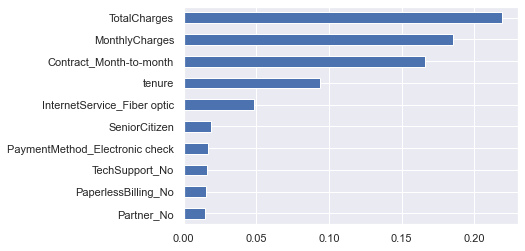

In [24]:
importances = dt_model.feature_importances_
weights = pd.Series(importances,
                 index=x.columns.values)
weights.sort_values()[-10:].plot(kind ='barh')

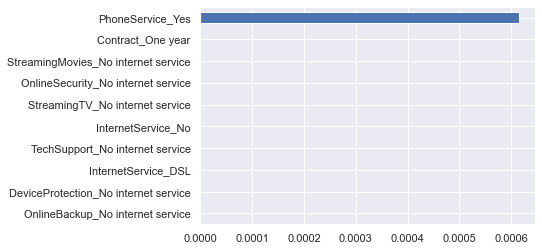

In [25]:
importances = dt_model.feature_importances_
weights = pd.Series(importances,
                 index=x.columns.values)
weights.sort_values()[:10].plot(kind = 'barh')

#### B: Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier(max_depth=20, random_state=0)
rfc_model.fit(x_train,y_train)

RandomForestClassifier(max_depth=20, random_state=0)

In [27]:
rfc_scored=rfc_model.score(x_test,y_test)
rfc_scored

0.7924662402274343

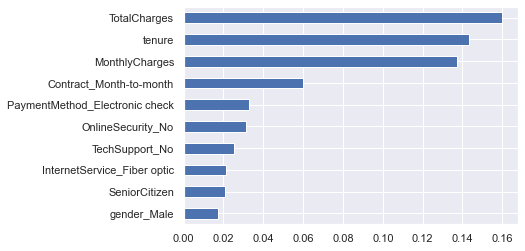

In [28]:
importances = rfc_model.feature_importances_
weights = pd.Series(importances,
                 index=x.columns.values)
weights.sort_values()[-10:].plot(kind = 'barh')

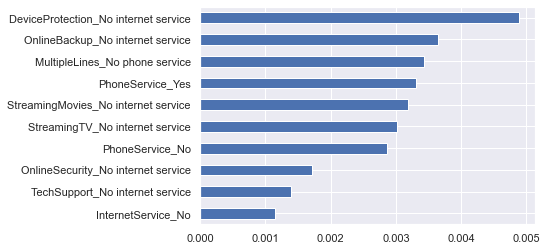

In [29]:
importances = rfc_model.feature_importances_
weights = pd.Series(importances,
                 index=x.columns.values)
weights.sort_values()[:10].plot(kind = 'barh')

#### C: Logistic Regression

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x, y, test_size=0.3, random_state=0)
from sklearn.linear_model import LogisticRegression
logr_model= LogisticRegression()
result = logr_model.fit(x_train, y_train)

In [31]:
logr_score=logr_model.score(x_test,y_test)
logr_score

0.7962085308056872

AxesSubplot(0.125,0.125;0.775x0.755)


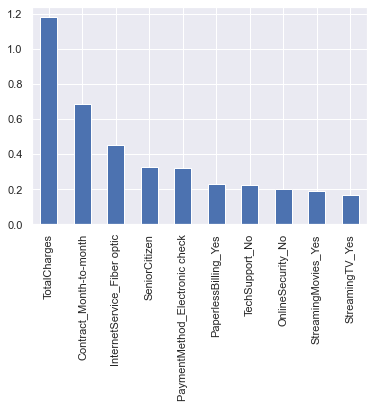

In [32]:
weights = pd.Series(logr_model.coef_[0],
                 index=x.columns.values)
print (weights.sort_values(ascending = False)[:10].plot(kind='bar'))

AxesSubplot(0.125,0.125;0.775x0.755)


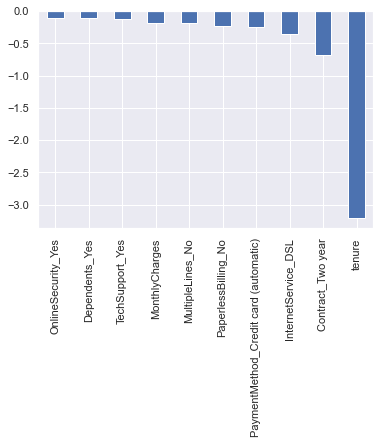

In [33]:
weights = pd.Series(logr_model.coef_[0],
                 index=x.columns.values)
print (weights.sort_values(ascending = False)[-10:].plot(kind='bar'))

Results:
* The Random forest Classifier out performed the decision tree, with an accuracy score of 79.24 percent and a maximum depth of the model was 20. That said there is a noticeable increase in the false negative result.
* Logistic Regression have an accuracy score of 79.62 percent and outperforming the other two models.
* The random forest model is outperforming the other two models.
* Total charges, monthly contracts and tenure are the most important features affect on churn accordingly tenure,total charges and contract-two year(vs. monthly contract) could be considered for recognizing loyal customers.

### Unsupervised learning:
#### <div style= "color:green">Loyal customer clustering</div>
In this section Loyal customers are clustered by 2 methods: K_means and Hierarchical method


Researches show that the cost of find new customer for each company is 5 time more than Cost of retaining current customers thuse the loyal customer are gold for each company.

-For cluster loyal customer I got help from RFM Model as following:

- Recency: unfortunately we dont have last contract date of customers and this attribute could not be calculated whit Teleco dataset information. 
- Frequency: this attribute could be observed by time of contract and tenure
- MonetaryValue: we could find this kind of loyal customer by total charges


#### A: Clustering using K-means method
Key steps done as flowing:
* Data pre-processing
* Choosing a number of clusters
* Running k-means clustering on pre-processed data 
* Analyzing average of each cluster


##### Data pre-processing done in below steps:
* Defining Three atributs(Frequency, MonetaryValue and tenure) as loyalty characteristics.
* Removing skew and Normalizing

In [34]:
df_dummies['Frequency']= (df_dummies['tenure']//24)*df_dummies['Contract_Two year']
print(df_dummies['Frequency'].max(), df_dummies['Frequency'].min())

3 0


In [35]:
df_dummies['MonetaryValue']=df_dummies['TotalCharges']

In [36]:
df_lc= df_dummies.loc[:,['tenure','MonetaryValue','Frequency']]
df_lc.head()

,tenure,MonetaryValue,Frequency
0,1,29.85,0
1,34,1889.50,0
2,2,108.15,0
3,45,1840.75,0
4,2,151.65,0


In [37]:
df_lc.describe()

,tenure,MonetaryValue,Frequency
count,7032.000000,7032.000000,7032.000000
mean,32.421786,2283.300441,0.452218
std,24.545260,2266.771362,0.898959
min,1.000000,18.800000,0.000000
25%,9.000000,401.450000,0.000000
50%,29.000000,1397.475000,0.000000
75%,55.000000,3794.737500,0.000000
max,72.000000,8684.800000,3.000000


In [38]:
df_lc['MonetaryValue']=np.log(df_lc['MonetaryValue'])
df_lc['tenure']=np.log(df_lc['tenure'])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_lc)
df_lc_normalized = scaler.transform(df_lc)
print('mean: ', df_lc_normalized.mean(axis=0).round(2))
print('std: ', df_lc_normalized.std(axis=0).round(2))

mean:  [ 0. -0. -0.]
std:  [1. 1. 1.]


##### Choosing a number of clusters:
 In order to ensure that too much modeling of the data is not given,the elbow method is used to determine optimal number of clusters. 

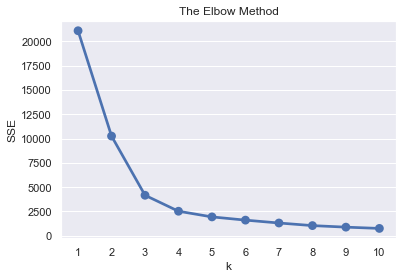

In [39]:
from sklearn.cluster import KMeans
import seaborn as sns
from matplotlib import pyplot as plt

sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(df_lc_normalized)
    sse[k] = kmeans.inertia_

plt.title('The Elbow Method')
plt.xlabel('k'); plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

Based on Elbow graph The optimum point for clustering is K=3

##### Running k-means clustering:

In [40]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(df_lc_normalized)
cluster_attribute_labels = kmeans.labels_

In [41]:
cluster_labels = kmeans.labels_
df_lc_k3=df_lc.assign(Cluster = cluster_labels)

In [42]:
df_lc_k3.groupby(['Cluster']).agg({
'tenure': 'mean'
,
'Frequency': 'mean'
,
'MonetaryValue': ['mean','count'],
}).round(0)

tenure Frequency MonetaryValue      
          mean      mean          mean count
Cluster                                     
0          3.0       0.0           8.0  3926
1          1.0       0.0           5.0  1822
2          4.0       2.0           8.0  1284

In [43]:
df_lc_normalized = pd.DataFrame(df_lc_normalized,index= df_lc.index,columns= df_lc.columns)
df_lc_normalized['Cluster'] = df_lc_k3['Cluster']

In [44]:
df_lc_melt = pd.melt(df_lc_normalized.reset_index(),
                     id_vars=['Cluster'],
                     value_vars=['tenure','MonetaryValue','Frequency'],
                     var_name='Attribute',
                     value_name='Value')

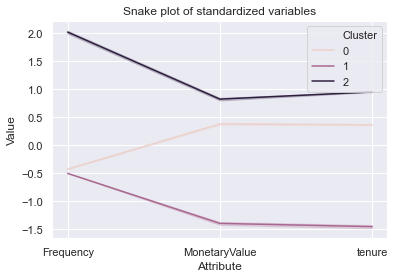

In [45]:
plt.title('Snake plot of standardized variables')
sns.lineplot(x="Attribute", y="Value", hue='Cluster', data=df_lc_melt)

It seems that cluster 2 is desired cluster for loyal customer segmentation

##### Analyzing average of each clusters:
For average of clusters analysis the clustering done for  K=4 and result shown in below:

In [46]:
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(df_lc_normalized)
cluster_attribute_labels = kmeans.labels_

In [47]:
cluster_labels = kmeans.labels_
df_lc_k4=df_lc.assign(Cluster = cluster_labels)

In [48]:
df_lc_k4.groupby(['Cluster']).agg({
'tenure': 'mean'
,
'Frequency': 'mean'
,
'MonetaryValue': ['mean','count'],
}).round(0)

tenure Frequency MonetaryValue      
          mean      mean          mean count
Cluster                                     
0          3.0       0.0           6.0  1801
1          4.0       2.0           8.0  1284
2          1.0       0.0           4.0  1394
3          4.0       0.0           8.0  2553

Comparing between mean tables with k=3 and k=4 shows that optimal cluster has not changing.

#### B: Hierarchical clustering:
Clustering done by Hierarchical method too; first at all optimum number of clusters obtained from dendrogram and clustering visualised by scatter plot. 

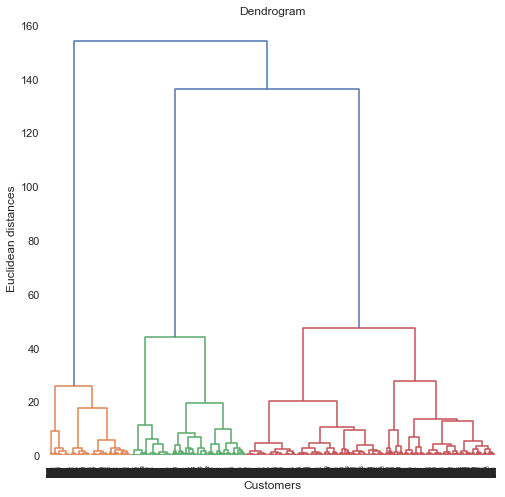

In [49]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(8,8))
dendrogram = sch.dendrogram(sch.linkage(df_lc_normalized, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

The combination of 3 lines are not joined on the Y-axis from 50 to 140, for about 90 units. So, the optimal number of clusters will be 3 for hierarchical clustering. 

In [50]:
x=df_lc_normalized[:]
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 3, affinity = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(x)

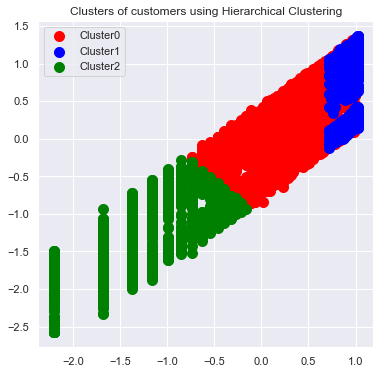

In [51]:
x= np.array(x)
plt.figure(figsize=(6,6))
plt.scatter(x[y_hc == 0, 0],x[y_hc == 0, 1], s = 100, c = 'red',label='Cluster0')
plt.scatter(x[y_hc == 1, 0],x[y_hc == 1, 1], s = 100, c = 'blue',label='Cluster1')
plt.scatter(x[y_hc == 2, 0],x[y_hc == 2, 1], s = 100, c = 'green',label='Cluster2')
plt.title('Clusters of customers using Hierarchical Clustering')
plt.legend()
plt.show()

cluster 1 is the best cluster in Hierarchical Clustering.